In [5]:
import torch
import torch.nn as nn

import numpy as np
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa
from utils.bam import MultiBAMv4, SymbolClassifier

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [ ]:
sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
second_layer = 1024
third_layer = 64

## ## Load BAM model and weight
BAM_layers = [input_col * input_row, second_layer, third_layer] # <-- must match training
multi_bam = MultiBAMv4(layers_dims=BAM_layers, eta=1e-5)
for i, bam in enumerate(multi_bam.bams):
    path = f"weight_{input_row*input_col}_{second_layer}_{third_layer}/weights_layer_{i}.npy"

    if os.path.isfile(path):
        w_np = np.load(path)
        bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
        print(f"✅ Loaded layer {i} | shape {bam.W.shape}")
    else:
        print(f"⚠️ Missing file for layer {i}: {path}")

## Load Classifier
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_layers = [third_layer,128,256, int(2**sf)]
model = SymbolClassifier(class_layers).to(device)
model.load_state_dict(torch.load("symbol_classifier.pt", map_location=device))

model.eval()   # 🔴 VERY IMPORTANT

✅ Loaded layer 0 | shape torch.Size([1024, 16896])
✅ Loaded layer 1 | shape torch.Size([64, 1024])


RuntimeError: Error(s) in loading state_dict for SymbolClassifier:
	Unexpected key(s) in state_dict: "net.4.weight", "net.4.bias". 
	size mismatch for net.0.weight: copying a param with shape torch.Size([128, 64]) from checkpoint, the shape in current model is torch.Size([256, 64]).
	size mismatch for net.0.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for net.2.weight: copying a param with shape torch.Size([256, 128]) from checkpoint, the shape in current model is torch.Size([512, 256]).
	size mismatch for net.2.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([512]).

In [ ]:
SNR_first = 5
SNR_last = -20
seed = None
if seed is not None:
    np.random.seed(seed)  # make noise reproducible
number_of_symbol_per_snr = 500
data_final = {}

BATCH = 20

for snr in range(SNR_first, SNR_last, -1):
    data_final[snr] = {"correct": 0, "false": 0}

    batch_X = []
    batch_y = []

    with torch.no_grad():
        for i, _ in enumerate(range(number_of_symbol_per_snr)):
            is_last = (i == number_of_symbol_per_snr - 1)
            r = np.random.randint(0, 512)

            x1 = lora_init.gen_symbol_fs(r, sf=sf, bw=bw, Fs=fs)
            x = lora_init.awgn_iq_with_seed(x1, snr, seed)

            input_spec = create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,0,0,1,None)
            flat = input_spec.flatten().reshape(1, -1)
            out = multi_bam.compress(flat).squeeze()

            batch_X.append(out)
            batch_y.append(r)

            if len(batch_X) == BATCH or is_last:
                X = torch.tensor(batch_X, dtype=torch.float32).to(device)
                X = X / (torch.norm(X, dim=1, keepdim=True) + 1e-8)

                logits = model(X)
                preds = logits.argmax(dim=1).cpu().numpy()

                for p, gt in zip(preds, batch_y):
                    if p == gt:
                        data_final[snr]["correct"] += 1
                    else:
                        data_final[snr]["false"] += 1

                batch_X.clear()
                batch_y.clear()

    # ---- METRICS ----
    total = data_final[snr]["correct"] + data_final[snr]["false"]
    acc = data_final[snr]["correct"] / total
    print(f"SNR {snr} dB | Accuracy = {acc * 100:.2f}%")

print(data_final)
import json

with open("evaluation_results.json", "w") as f:
    json.dump(data_final, f, indent=4)



c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\bam.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32, device=self.device)
C:\Users\priba\AppData\Local\Temp\ipykernel_34044\4062710828.py:33: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  X = torch.tensor(batch_X, dtype=torch.float32).to(device)


SNR 5 dB | Accuracy = 9.60%
SNR 4 dB | Accuracy = 8.40%
SNR 3 dB | Accuracy = 6.60%
SNR 2 dB | Accuracy = 6.60%
SNR 1 dB | Accuracy = 8.20%
SNR 0 dB | Accuracy = 4.60%
SNR -1 dB | Accuracy = 7.80%
SNR -2 dB | Accuracy = 8.20%
SNR -3 dB | Accuracy = 6.00%
SNR -4 dB | Accuracy = 7.80%
SNR -5 dB | Accuracy = 5.20%
SNR -6 dB | Accuracy = 4.80%
SNR -7 dB | Accuracy = 5.00%
SNR -8 dB | Accuracy = 2.40%
SNR -9 dB | Accuracy = 2.80%
SNR -10 dB | Accuracy = 3.40%
SNR -11 dB | Accuracy = 2.40%
SNR -12 dB | Accuracy = 2.20%
SNR -13 dB | Accuracy = 2.20%
SNR -14 dB | Accuracy = 1.00%
SNR -15 dB | Accuracy = 0.60%
SNR -16 dB | Accuracy = 1.20%
SNR -17 dB | Accuracy = 1.00%
SNR -18 dB | Accuracy = 0.20%
SNR -19 dB | Accuracy = 0.20%
{5: {'correct': 48, 'false': 452}, 4: {'correct': 42, 'false': 458}, 3: {'correct': 33, 'false': 467}, 2: {'correct': 33, 'false': 467}, 1: {'correct': 41, 'false': 459}, 0: {'correct': 23, 'false': 477}, -1: {'correct': 39, 'false': 461}, -2: {'correct': 41, 'false': 45

{5: {'correct': 48, 'false': 452}, 4: {'correct': 42, 'false': 458}, 3: {'correct': 33, 'false': 467}, 2: {'correct': 33, 'false': 467}, 1: {'correct': 41, 'false': 459}, 0: {'correct': 23, 'false': 477}, -1: {'correct': 39, 'false': 461}, -2: {'correct': 41, 'false': 459}, -3: {'correct': 30, 'false': 470}, -4: {'correct': 39, 'false': 461}, -5: {'correct': 26, 'false': 474}, -6: {'correct': 24, 'false': 476}, -7: {'correct': 25, 'false': 475}, -8: {'correct': 12, 'false': 488}, -9: {'correct': 14, 'false': 486}, -10: {'correct': 17, 'false': 483}, -11: {'correct': 12, 'false': 488}, -12: {'correct': 11, 'false': 489}, -13: {'correct': 11, 'false': 489}, -14: {'correct': 5, 'false': 495}, -15: {'correct': 3, 'false': 497}, -16: {'correct': 6, 'false': 494}, -17: {'correct': 5, 'false': 495}, -18: {'correct': 1, 'false': 499}, -19: {'correct': 1, 'false': 499}}
[-19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]


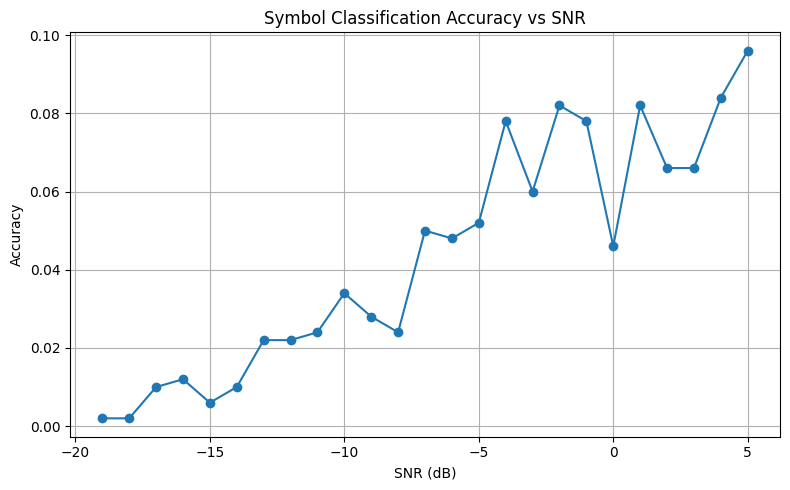

In [ ]:
with open("evaluation_results.json", "r") as f:
    data_final = json.load(f)
# Convert SNR keys back to int
data_final = {int(k): v for k, v in data_final.items()}
print(data_final)
snrs = sorted(data_final.keys())
print(snrs)
accuracy = []

for snr in snrs:
    correct = data_final[snr]["correct"]
    total = correct + data_final[snr]["false"]
    accuracy.append(correct / total)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(snrs, accuracy, marker='o')
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Symbol Classification Accuracy vs SNR")
plt.grid(True)
plt.gca()
plt.tight_layout()
plt.show()